### Importing Libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Loading Dataset

In [3]:
customerseg = pd.read_csv("/content/drive/MyDrive/Shopping Mall Customer Segmentation Data  (1).csv")
customerseg

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76
...,...,...,...,...,...
15074,a0504768-a85f-4930-ac24-55bc8e4fec9e,29,Female,97723,30
15075,a08c4e0e-d1fe-48e7-9366-aab11ae409cd,22,Male,73361,74
15076,0e87c25a-268c-401a-8ba1-7111dcde6f1a,18,Female,112337,48
15077,5f388cbe-3373-4e16-b743-38f508f2249f,26,Female,94312,5


### Copying Dataframe

In [4]:
df = customerseg.copy()

#### Explore the Dataset:

In [5]:
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [6]:
df.dtypes

,0
Customer ID,object
Age,int64
Gender,object
Annual Income,int64
Spending Score,int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.1+ KB


In [8]:
df.shape

(15079, 5)

In [9]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Annual Income', 'Spending Score'], dtype='object')

In [10]:
df.describe()

,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


#### Checking NULL Values:

In [11]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Annual Income,0
Spending Score,0


#### Checking For Duplicates

In [12]:
df.duplicated().sum()

0

#### Encoding the categorical column

In [13]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})


#### Scale numerical features:

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Annual Income', 'Spending Score']] = scaler.fit_transform(df[['Annual Income', 'Spending Score']])


### Find Optimal Clusters (K-Means)

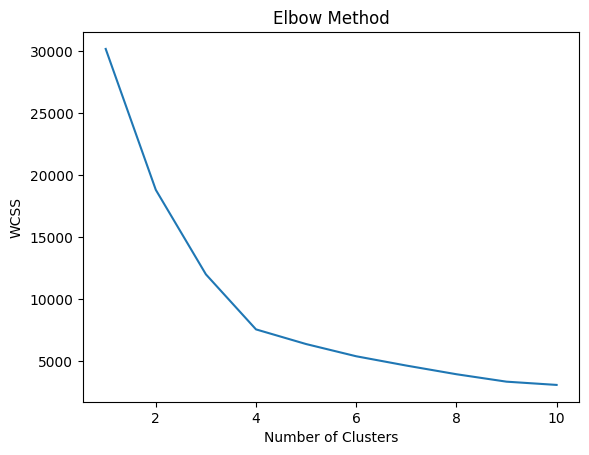

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df[['Annual Income', 'Spending Score']])
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


#### Apply K-Means Clustering

In [16]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['Annual Income', 'Spending Score']])

### Visualize Clusters

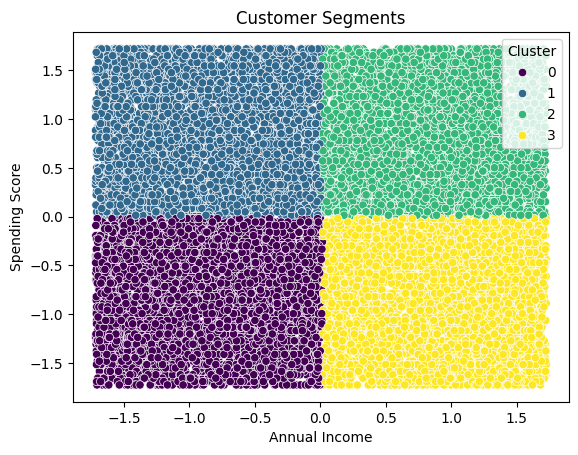

In [17]:
import seaborn as sns
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Cluster', palette='viridis')
plt.title('Customer Segments')
plt.show()



This visualization represents customer segmentation based on their Annual Income (x-axis) and Spending Score (y-axis). The clusters (0, 1, 2, 3) represent distinct groups of customers with similar behaviors. Here's how to interpret it:

Cluster 0 (Purple):
Customers with lower spending scores and lower annual incomes. Likely less engaged or budget-conscious shoppers.

Cluster 1 (Blue):
Customers with higher spending scores but lower annual incomes. They may prioritize spending despite limited income.

Cluster 2 (Green):
Customers with higher spending scores and higher annual incomes. Likely the most valuable customers for marketing focus.

Cluster 3 (Yellow):
Customers with lower spending scores but higher annual incomes. They have potential for higher spending but may need engagement.

This segmentation helps identify targeted strategies for each group, such as tailored marketing or personalized offers!